In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
img = files.upload()

Saving ja-mong-rannier-w.jpg to ja-mong-rannier-w.jpg


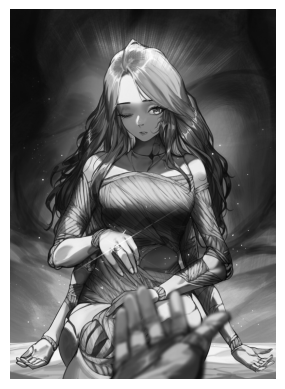

In [14]:
img_gbr = cv2.imread("ja-mong-rannier-w.jpg", cv2.IMREAD_COLOR_RGB)
img_gray = cv2.cvtColor(img_gbr, cv2.COLOR_BGR2GRAY)
plt.axis("off")
plt.imshow(img_gray, cmap="gray")

In [15]:
altura, largura = img_gray.shape[0],img_gray.shape[1]
altura, largura

(1673, 1200)

# Translação de Exclusão

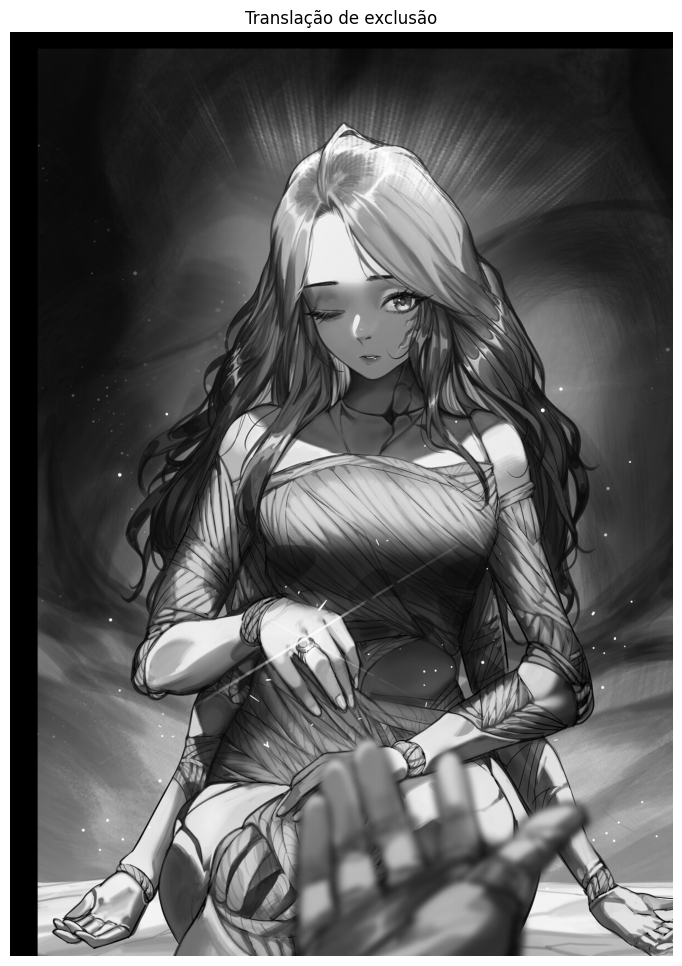

In [16]:
dx = 50
dy = 30

transladada = np.zeros((altura, largura), np.uint8)

for x in range(largura):
  for y in range(altura):
    novo_x = x + dx
    novo_y = y + dy

    if 0 <= novo_x and novo_x < largura:
      if 0 <= novo_y and novo_y < altura:
        transladada[novo_y, novo_x] = img_gray[y,x]

plt.figure(figsize=(16,12))
plt.imshow(transladada, cmap="gray")
plt.title("Translação de exclusão")
plt.axis("off")
plt.show()

# Translação wrap-around

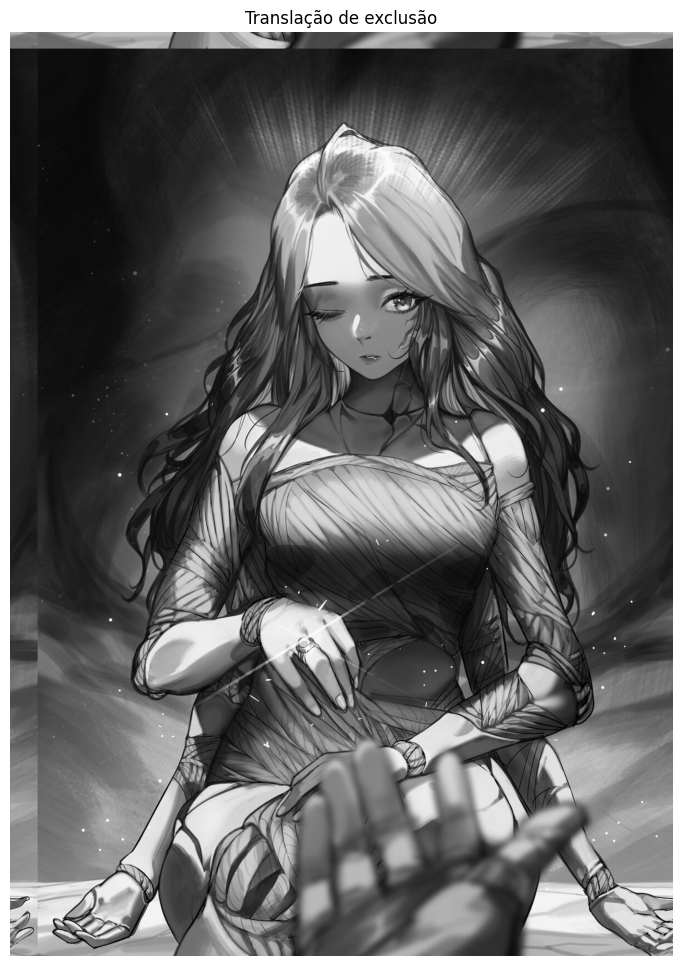

In [17]:
dx = 50
dy = 30

transladada = np.zeros((altura, largura), np.uint8)

for x in range(largura):
  for y in range(altura):
    novo_x = (x + dx) % largura
    novo_y = (y + dy) % altura

    if 0 <= novo_x and novo_x < largura:
      if 0 <= novo_y and novo_y < altura:
        transladada[novo_y, novo_x] = img_gray[y,x]

plt.figure(figsize=(16,12))
plt.imshow(transladada, cmap="gray")
plt.title("Translação de exclusão")
plt.axis("off")
plt.show()

# Escalonamento

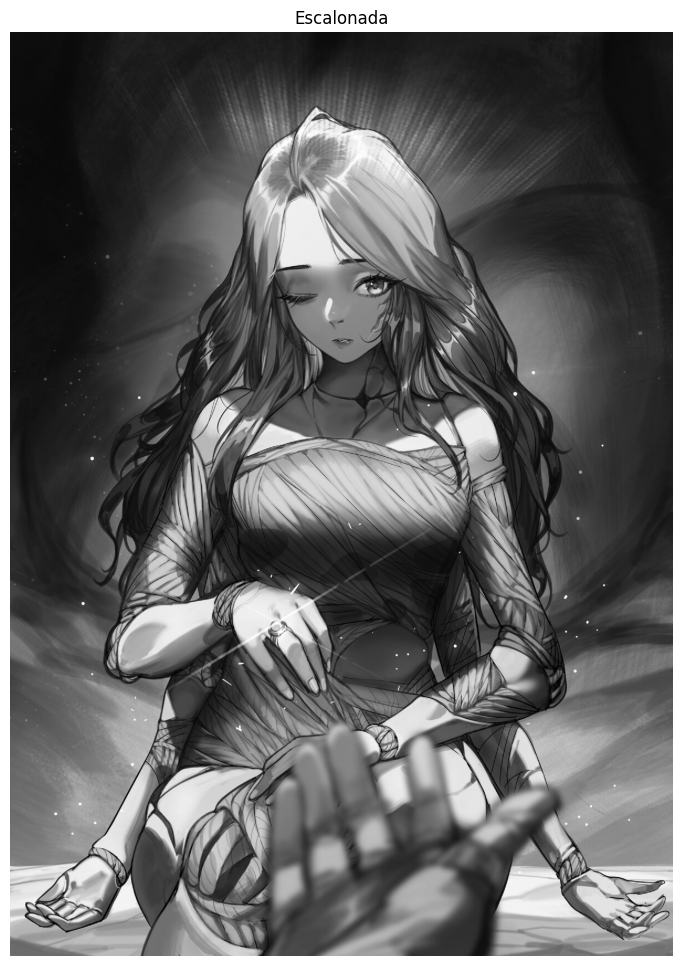

In [23]:
sx = 1.5
sy = 1.5

nova_largura = int(largura*sx)
nova_altura = int(altura*sy)

escalada = np.zeros((nova_altura, nova_largura), np.uint8)

for x in range(nova_largura):
  for y in range(nova_altura):

    novo_x = int(x/sx)
    novo_y = int(y/sy)

    escalada[y,x] = img_gray[novo_y, novo_x]


plt.figure(figsize=(16,12))
plt.imsave('ranni.jpg', escalada)
plt.imshow(escalada, cmap="gray")
plt.title("Escalonada")
plt.axis("off")
plt.show()

# Espalhamento

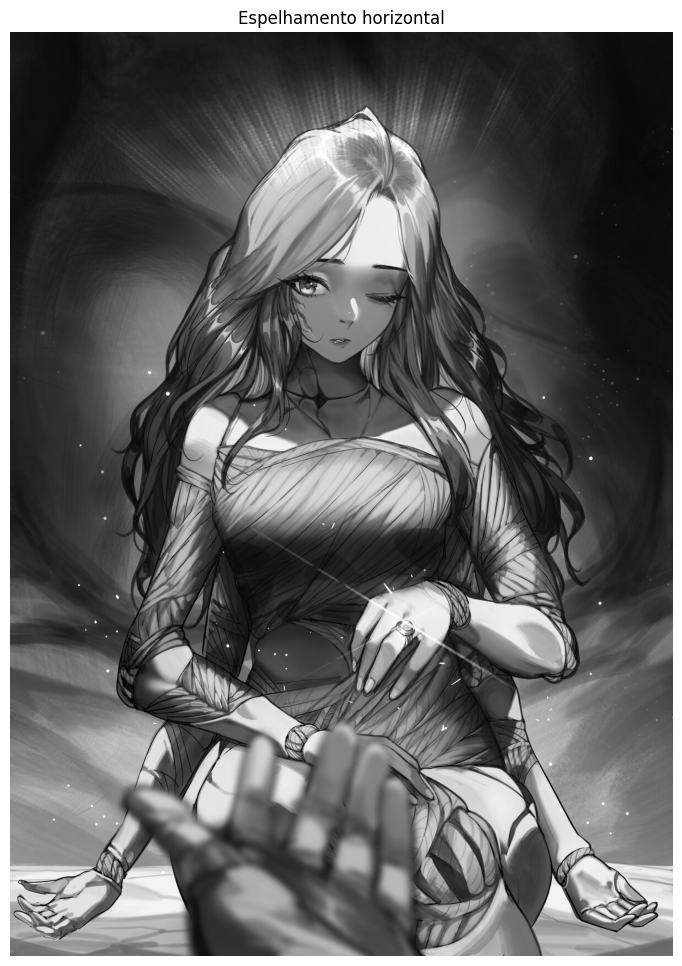

In [24]:
espelhada = np.zeros((altura, largura), np.uint8)

for x in range(largura):
  for y in range(altura):

    novo_x = largura - 1 - x

    espelhada[y,novo_x] = img_gray[y, x]


plt.figure(figsize=(16,12))
plt.imsave('ranni_espelhada.jpg', espelhada)
plt.imshow(espelhada, cmap="gray")
plt.title("Espelhamento horizontal")
plt.axis("off")
plt.show()